## 各船の船舶ログから偏流を計算するまでの流れ
1. 複数のログファイルをFileConection.ipynbで１つのファイルにする
1. S1-ShipLogToS1でファイルから必要な情報を抜き出す
1. このファイル(環境省の船舶ログから偏流)で各船の偏流を計算

In [12]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
import tqdm
import pickle as pkl
import math
import os 
import os.path as osp

from utils import *
from kf_params import *

In [199]:
log_data = None
path_log = "./data/shipLog/2016-0919/中春"
filename = "中春丸FileOut20160919.slog1"
log = pd.read_csv(osp.join(path_log, filename), encoding="cp932", header=None)
if log_data==None:
    log_data = log
else:
    log_data = pd.concat([log_data, log])
log_data.columns = ["JST", "NMEA", "data1", "data2"]

In [200]:
log_data

,JST,NMEA,data1,data2
0,2016/09/18 15:00:00,VBW,12.000,-999.000
1,2016/09/18 15:00:00,GGA,3542.860,13331.052
2,2016/09/18 15:00:00,VTG,85.000,12.000
3,2016/09/18 15:00:00,HDT,85.000,NaN
4,2016/09/18 15:00:01,GGA,3542.861,13331.060
...,...,...,...,...
380089,2016/09/19 14:59:59,VTG,281.400,0.100
380090,2016/09/19 14:59:59,HDT,344.000,NaN
380091,2016/09/19 14:59:59,GGA,3529.820,13521.640
380092,2016/09/19 14:59:59,VTG,281.400,0.100


In [210]:
# 時間の整理
time_utc =log_data["JST"].values
str_format = '%Y/%m/%d %H:%M:%S'
epoc_dt = datetime.datetime(2011, 1, 1, 0, 0, 0)
time_idx = []
tf = []
for t in time_utc:
    idx = datetime.datetime.strptime(t, str_format) 
    idx2 = idx - epoc_dt
    time_idx.append(int(idx2.days*24*60 + idx2.seconds / (60)))
time_idx = np.array(time_idx)
log_data["DtIdx"] = time_idx

min_dt = datetime.datetime(2015, 9, 19, 0, 0, 0)
min_idx = min_dt - epoc_dt
min_idx = int(min_idx.days*24*60 + min_idx.seconds / (60))
log_data = log_data[log_data["DtIdx"] >= min_idx]

gga = log_data[log_data["NMEA"]=="GGA"]
gga.columns = gga.columns = ['JST', 'NMEA', 'Lat', 'Lon', 'DtIdx']

vbw = log_data[log_data["NMEA"]=="VBW"]
vbw.columns = ['JST', 'NMEA', 'LonWaterSpeed', 'TraWaterSpeed', 'DtIdx']

hdt = log_data[log_data["NMEA"]=="HDT"]
hdt = hdt.drop('data2', axis=1)
hdt.columns = ['JST', 'NMEA', 'HeadDeg', 'DtIdx']

vtg = log_data[log_data["NMEA"]=="VTG"]
vtg.columns = ['JST', 'NMEA', 'HeadDeg', 'GroundSpeed', 'DtIdx']

In [219]:
values_set = set((vbw["LonWaterSpeed"]).astype(str) + " " 
                 + vbw["TraWaterSpeed"].astype(str))

forbidden_values = {'0.0 0.0', '0.0 -999.0', '-999.0 0.0', '-999.0 -999.0'}
dtIdx = []
lonSpeed = []
traSpeed = []
for v in values_set:
    tf = (v == (vbw["LonWaterSpeed"]).astype(str) + " " 
                + vbw["TraWaterSpeed"].astype(str))
    if not v in forbidden_values:
        dtIdx.append(vbw[tf]['DtIdx'].values.tolist())
        ls = vbw[tf]['LonWaterSpeed'].values
        ls[ls==-999.0] = 0.0
        lonSpeed.append(ls.tolist())
        ts = vbw[tf]['TraWaterSpeed'].values
        ts[ts==-999.0] = 0.0
        traSpeed.append(ts.tolist())
dtIdx = sum(dtIdx, [])
lonSpeed = sum(lonSpeed, [])
traSpeed = sum(traSpeed, [])

vbw2 = pd.DataFrame([])
vbw2['DtIdx'] = dtIdx
vbw2['LonWaterSpeed'] = lonSpeed
vbw2['TraWaterSpeed'] = traSpeed
vbw = vbw2

In [217]:

def mean_ground_speed(dt, lat1, lon1, lat2, lon2):
    
    lat1 = dms_to_deg(lat1)
    lon1 = dms_to_deg(lon1)
    
    lat2 = dms_to_deg(lat2)
    lon2 = dms_to_deg(lon2)
    
    #print(f"{lat1}, {lon1}")
    #print(f"{lat2}, {lon2}")
    dist, deg = dist_deg_latlon(lat1, lon1, lat2, lon2)
    speed = dist/dt
    return ((lat1+lat2)/2, (lon1+lon2)/2), (speed, deg)

def dist_deg_latlon(lat1, lon1, lat2, lon2):
    from geopy.distance import geodesic
    res = geodesic((lat1, lon1), (lat2, lon2))
    # 方位角を計算
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    delta_lon = lon2_rad - lon1_rad
    y = math.sin(delta_lon) * math.cos(lat2_rad)
    x = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(delta_lon)
    bearing = math.degrees(math.atan2(y, x))

    # 0から360度の範囲に調整
    bearing = (bearing + 360) % 360
    return res.meters, bearing

def dms_to_deg(x):
    deg = x // 100
    mit = int(x - deg*100)
    sec = (x - int(x))*100
    #print(x)
    #print(deg)
    #print(mit)
    #print(sec)
    return deg + mit/60 + sec/3600

In [220]:

dt = 30
dt_min = gga["DtIdx"].values[0]
dts = []
curN = []
curE = []
lats = []
lons = []
grids0 = []
grids1 = []
while(gga["DtIdx"].values[-1] > dt_min+dt*2):
    #print(dt_min)
    dt_range1 = [dt_min, dt_min+dt]
    dt_range2 = [dt_min+dt+1, dt_min+dt*2]
    dt_range = [dt_range1[0], dt_range2[1]]
    
    vbw1 = vbw[vbw["DtIdx"] > dt_range[0]]
    vbw1 = vbw1[vbw1["DtIdx"] < dt_range[1]]
    if (len(vbw1.values)==0):
        dt_min += 5
        contiue
    water_speed = np.mean(vbw1["LonWaterSpeed"].values)
    
    gga1 = gga[gga["DtIdx"] > dt_range1[0]]
    gga1 = gga1[gga1["DtIdx"] < dt_range1[1]]
    gga2 = gga[gga["DtIdx"] > dt_range2[0]]
    gga2 = gga2[gga2["DtIdx"] < dt_range2[1]]
    
    lat1 = np.mean(gga1["Lat"])
    lon1 = np.mean(gga1["Lon"])
    lat2 = np.mean(gga2["Lat"])
    lon2 = np.mean(gga2["Lon"])
    latlon, vec = mean_ground_speed(dt, lat1, lon1, lat2, lon2)
    ground_speed, deg = vec
    deg = (-deg-90)*np.pi/180

    hdt1 = hdt[hdt["DtIdx"] > dt_range[0]]
    hdt1 = hdt1[hdt1["DtIdx"] <dt_range[1]]
    heading = np.mean(hdt1["HeadDeg"].values)
    heading = (-heading-90)*np.pi/180
    
    grid0, grid1 = latlon_to_mesh(latlon[0], latlon[1])

    dts.append(gga1["DtIdx"].values[0]+dt)
    curN.append(ground_speed*np.sin(deg) - water_speed*np.sin(heading))
    curE.append(ground_speed*np.cos(deg) - water_speed*np.cos(heading))
    lats.append(latlon[0])
    lons.append(latlon[1])
    grids0.append(grid0)
    grids1.append(grid1)
    dt_min += 5

cur = pd.DataFrame([])
cur["Time minutes"] = dts
cur["CurN"] = curN
cur["CurE"] = curE
cur["Lat"] = lats
cur["Lon"] = lons
cur["Grid0"] = grids0
cur["Grid1"] = grids1

In [221]:
cur

,Time minutes,CurN,CurE,Lat,Lon,Grid0,Grid1
0,3006211,-49.534994,-342.014094,35.730136,133.648691,600,567
1,3006216,-46.268475,-376.420942,35.733774,133.665921,600,567
2,3006221,-41.595222,-378.430201,35.737489,133.688773,601,567
3,3006226,-37.047473,-379.612986,35.741200,133.711645,602,567
4,3006231,-32.831662,-346.478855,35.744839,133.728988,603,567
...,...,...,...,...,...,...,...
271,3007566,1.536212,1.885744,35.506340,135.367893,662,559
272,3007571,0.863717,1.262368,35.506277,135.367854,662,559
273,3007576,0.466407,0.417739,35.506237,135.367818,662,559
274,3007581,0.254630,-0.466658,35.506209,135.367776,662,559


In [222]:
m_curN = np.mean(cur["CurN"].values)
m_curE = np.mean(cur["CurE"].values)
std_curN = np.std(cur["CurN"].values)
std_curE = np.std(cur["CurE"].values)
print(f"curN:{m_curN}, std:{std_curN}")
print(f"curE:{m_curE}, std:{std_curE}")

curN:17.264566519229334, std:86.76810590007317
curE:-98.19879624446753, std:328.71473744022927


<Axes: xlabel='Lon', ylabel='Lat'>

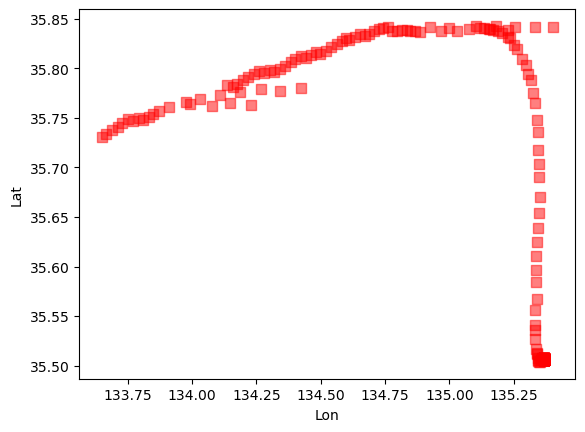

In [223]:
cur.plot.scatter(x='Lon', y='Lat',
                marker='s', c='r', s=50, alpha=0.5)

In [224]:
# 保存
cur.to_csv(osp.join(path_log, "cur_minutes.csv"))

In [225]:
time_grid_set = set((cur["Time minutes"]//60).astype(str) + " " 
                    + cur["Grid0"].astype(str) + " " 
                    + (cur["Grid1"].astype(str)))

min_timeHours = np.min(cur["Time minutes"].values//60)
max_timeHours = np.max(cur["Time minutes"].values//60)
num_timeHours = max_timeHours - min_timeHours + 1

grids0 = []
grids1 = []
curN = []
curE = []
timeHours = []
curN_grid = [np.zeros(nan_map.shape) for _ in range(num_timeHours)]
curE_grid = [np.zeros(nan_map.shape) for _ in range(num_timeHours)]
count_grid = [np.zeros(nan_map.shape) for _ in range(num_timeHours)]

for time_grid in time_grid_set:
        target_tf = (time_grid == (cur["Time minutes"]//60).astype(str) + " " 
                                 +  cur["Grid0"].astype(str) + " "  
                                 + (cur["Grid1"].astype(str)))
        target = cur[target_tf]
        timeHours.append((target["Time minutes"]).values[0]//60 - min_timeHours)
        grids0.append(target["Grid0"].values[0])
        grids1.append(target["Grid1"].values[0])
        curN.append(np.mean(target["CurN"].values))
        curE.append( np.mean(target["CurE"].values))
        curN_grid[timeHours[-1]][grids0[-1]][grids1[-1]] += curN[-1]
        curE_grid[timeHours[-1]][grids0[-1]][grids1[-1]] += curE[-1]
        count_grid[timeHours[-1]][grids0[-1]][grids1[-1]] += 1

grid_cur = pd.DataFrame([])
grid_cur["Time hours"] = timeHours
grid_cur["CurN"] = curN
grid_cur["CurE"] = curE
grid_cur["Grid0"] = grids0
grid_cur["Grid1"] = grids1

for i in range(num_timeHours):
    count_grid[i][count_grid[i] == 0] += 1
    curN_grid[i] = curN_grid[i]/count_grid[i]
    curE_grid[i] = curE_grid[i]/count_grid[i]

In [195]:
grid_cur = grid_cur.sort_values('Time hours')
grid_cur = grid_cur.reset_index(drop=True)


In [196]:
# 各時間のデータ数
pd.value_counts(grid_cur["Time hours"])

22    12
20     9
19     9
16     6
15     6
21     5
18     5
17     5
14     5
5      4
6      4
23     3
13     1
0      1
1      1
11     1
10     1
9      1
8      1
7      1
4      1
3      1
2      1
12     1
Name: Time hours, dtype: int64

In [197]:
# 保存
grid_cur.to_csv(osp.join(path_log, "cur_hours.csv"))

In [198]:
pkl.dump(curN_grid, open(osp.join(path_log, "curGridN_hours.pkl"), 'wb'))
pkl.dump(curE_grid, open(osp.join(path_log, "curGridE_hours.pkl"), 'wb'))